# Pure-Python Active Learning Toy Demo

This notebook is a minimal active-learning testbed inspired by Lookman et al.

Design choices for simplicity:
- No external ML libraries
- Surrogate model: piecewise linear interpolation between sampled points
- Uncertainty proxy: distance to nearest sampled point

This is not a production surrogate model, but it is useful for understanding the active-learning loop and targeted sampling behavior.

In [1]:
import math
import random

random.seed(13)

In [14]:
# Synthetic expensive function (unknown in real experiments)
def f(x):
    return math.sin(3.0 * x) + 0.25 * (x - 2.0) ** 2

# Candidate design points
x_min, x_max = 0.0, 4.0
n_grid = 301
X_GRID = [x_min + i * (x_max - x_min) / (n_grid - 1) for i in range(n_grid)]
Y_TRUE = [f(x) for x in X_GRID]

target_y = 0.30
budget = 100 #24*20
n_init = 4

In [15]:
def surrogate_predict(x, sampled_xy):
    """
    Piecewise linear interpolation mean + nearest-sample distance uncertainty proxy.
    sampled_xy: list of (x, y), sorted by x
    """
    n = len(sampled_xy)

    # Distance to nearest sampled x -> uncertainty proxy
    dmin = min(abs(x - sx) for sx, _ in sampled_xy)

    # Extrapolation at boundaries
    if x <= sampled_xy[0][0]:
        return sampled_xy[0][1], dmin
    if x >= sampled_xy[-1][0]:
        return sampled_xy[-1][1], dmin

    # Interpolate in the enclosing segment
    for i in range(n - 1):
        x0, y0 = sampled_xy[i]
        x1, y1 = sampled_xy[i + 1]
        if x0 <= x <= x1:
            if x1 == x0:
                return y0, dmin
            t = (x - x0) / (x1 - x0)
            mu = y0 + t * (y1 - y0)
            return mu, dmin

    # Fallback should never happen
    return sampled_xy[-1][1], dmin


def run_active_learning(strategy='uncertainty', target=0.0, alpha_target=1.0):
    chosen_idx = random.sample(range(len(X_GRID)), n_init)
    chosen_idx.sort()

    history_best = []

    while len(chosen_idx) < budget:
        sampled_xy = sorted((X_GRID[i], Y_TRUE[i]) for i in chosen_idx)

        best_idx = None
        best_score = -1e300

        chosen_set = set(chosen_idx)
        for i, x in enumerate(X_GRID):
            if i in chosen_set:
                continue

            mu, u = surrogate_predict(x, sampled_xy)

            if strategy == 'uncertainty':
                score = u
            elif strategy == 'targeted':
                score = u - alpha_target * abs(mu - target)
            else:
                raise ValueError('Unknown strategy: ' + str(strategy))

            if score > best_score:
                best_score = score
                best_idx = i

        chosen_idx.append(best_idx)
        chosen_idx.sort()

        best_dist = min(abs(Y_TRUE[i] - target) for i in chosen_idx)
        history_best.append(best_dist)

    return chosen_idx, history_best


def run_random(target=0.0):
    idx = random.sample(range(len(X_GRID)), budget)
    history_best = []

    for k in range(n_init, budget):
        subset = idx[:k + 1]
        best_dist = min(abs(Y_TRUE[i] - target) for i in subset)
        history_best.append(best_dist)

    return idx, history_best

In [16]:
idx_unc, hist_unc = run_active_learning(strategy='uncertainty', target=target_y)
idx_tar, hist_tar = run_active_learning(strategy='targeted', target=target_y, alpha_target=1.3)
idx_rnd, hist_rnd = run_random(target=target_y)

best_unc = min(abs(Y_TRUE[i] - target_y) for i in idx_unc)
best_tar = min(abs(Y_TRUE[i] - target_y) for i in idx_tar)
best_rnd = min(abs(Y_TRUE[i] - target_y) for i in idx_rnd)

print('Best |y-target| after budget:')
print('  Uncertainty AL:', round(best_unc, 6))
print('  Targeted AL:   ', round(best_tar, 6))
print('  Random:        ', round(best_rnd, 6))

print('\nSampled x locations (targeted AL):')
print([round(X_GRID[i], 3) for i in idx_tar])

Best |y-target| after budget:
  Uncertainty AL: 0.01349
  Targeted AL:    0.001602
  Random:         0.001602

Sampled x locations (targeted AL):
[0.467, 0.893, 0.907, 0.92, 0.933, 0.947, 0.96, 0.973, 0.987, 1.0, 1.013, 1.027, 1.04, 1.053, 1.067, 1.08, 1.093, 1.107, 1.12, 1.133, 1.147, 1.16, 1.573, 2.027, 2.053, 2.067, 2.08, 2.093, 2.107, 2.12, 2.133, 2.147, 2.16, 2.173, 2.187, 2.2, 2.213, 2.227, 2.24, 2.253, 2.267, 2.28, 2.293, 2.307, 2.32, 2.333, 2.347, 2.36, 2.467, 2.693, 2.92, 2.973, 2.987, 3.0, 3.013, 3.027, 3.04, 3.053, 3.067, 3.08, 3.093, 3.107, 3.12, 3.133, 3.147, 3.16, 3.173, 3.187, 3.2, 3.213, 3.227, 3.24, 3.253, 3.267, 3.28, 3.293, 3.307, 3.32, 3.333, 3.347, 3.36, 3.387, 3.587, 3.787, 3.8, 3.813, 3.827, 3.84, 3.853, 3.867, 3.88, 3.893, 3.907, 3.92, 3.933, 3.947, 3.96, 3.973, 3.987, 4.0]


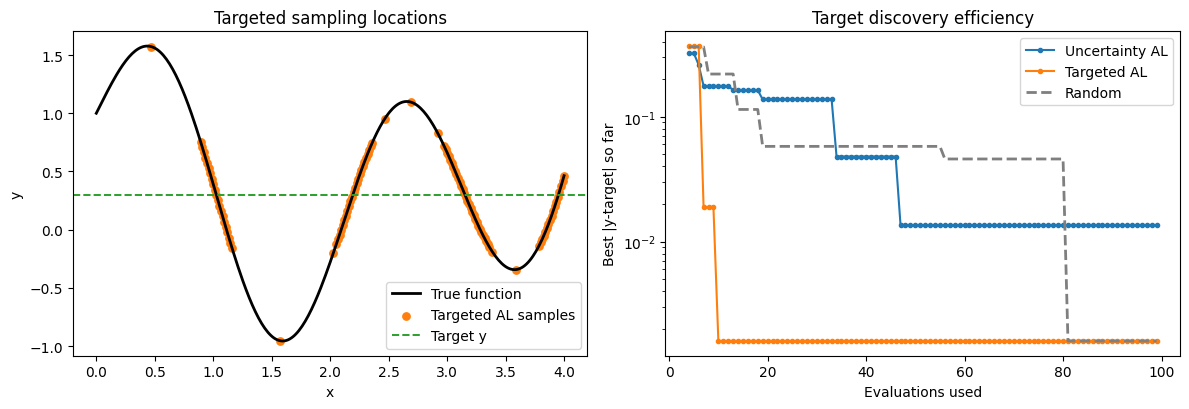

In [17]:
# Optional plotting if matplotlib is available
try:
    import matplotlib.pyplot as plt

    xs_unc = [k for k in range(n_init, budget)]
    xs_tar = [k for k in range(n_init, budget)]
    xs_rnd = [k for k in range(n_init, budget)]

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

    ax[0].plot(X_GRID, Y_TRUE, 'k-', lw=2, label='True function')
    ax[0].scatter([X_GRID[i] for i in idx_tar], [Y_TRUE[i] for i in idx_tar], c='C1', s=28, label='Targeted AL samples')
    ax[0].axhline(target_y, color='C2', ls='--', lw=1.4, label='Target y')
    ax[0].set_xlabel('x')
    ax[0].set_ylabel('y')
    ax[0].set_title('Targeted sampling locations')
    ax[0].legend()

    ax[1].plot(xs_unc, hist_unc, 'C0-o', ms=3, label='Uncertainty AL')
    ax[1].plot(xs_tar, hist_tar, 'C1-o', ms=3, label='Targeted AL')
    ax[1].plot(xs_rnd, hist_rnd, 'C7--', lw=2, label='Random')
    ax[1].set_xlabel('Evaluations used')
    ax[1].set_ylabel('Best |y-target| so far')
    ax[1].set_yscale('log')
    ax[1].set_title('Target discovery efficiency')
    ax[1].legend()

    plt.tight_layout()
    plt.show()
except Exception as e:
    print('matplotlib unavailable, skipping plots:', e)

In [10]:
target_y

0.3

## How to adapt this

Replace `f(x)` with your simulator/experiment call and `X_GRID` with your candidate design set.
The active loop logic can remain unchanged.